# IMPORTS

## Deep Learning & Core API

In [1]:
import tensorflow as tf                     
from tensorflow import keras               
from tensorflow.keras import layers, regularizers
from tensorflow.keras import backend as K   

2025-08-21 13:16:45.462788: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-21 13:16:45.462848: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-21 13:16:45.465091: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-21 13:16:45.473645: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Handling & Augmentation

In [2]:
import numpy as np                         
import pandas as pd                         
from sklearn.utils import shuffle           
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

## Metrics

In [3]:
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score
)

## Plotting

In [4]:
import matplotlib.pyplot as plt
plt.style.use("default")

## Image Ops

In [5]:
!pip install opencv-python-headless --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
matplotlib 3.8.2 requires numpy<2,>=1.21, but you have numpy 2.2.6 which is incompatible.
tensorflow 2.15.0 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.2.6 which is incompatible.

[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [6]:
import cv2
print(cv2.__version__)

4.12.0


## Experiment Tracking & Env

In [7]:
from comet_ml import Experiment
from dotenv import load_dotenv

## System & Utilities

In [8]:
import os, shutil, datetime, random

# GPU Settings

In [9]:
# List all physical devices available to TensorFlow (CPUs, GPUs, etc.)
devices = tf.config.list_physical_devices()
print("Devices:", devices)

# Query for the default GPU device name (if any)
device_name = tf.test.gpu_device_name()
# If TensorFlow did not detect a GPU at '/device:GPU:0', raise an error
if device_name != '/device:GPU:0':
    raise SystemError('GPU device not found')
# Confirm that the GPU was found
print('Found GPU at: {}'.format(device_name))

# Set the default device context to the GPU for subsequent ops
tf.device('/device:GPU:0')

Devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found GPU at: /device:GPU:0


2025-08-21 13:16:55.026847: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /device:GPU:0 with 79078 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:61:00.0, compute capability: 8.0
2025-08-21 13:16:55.033786: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79078 MB memory:  -> device: 0, name: NVIDIA A100 80GB PCIe, pci bus id: 0000:61:00.0, compute capability: 8.0


# Comet Experiment

In [10]:
# Initialize a Comet.ml experiment for tracking metrics, parameters, and model artifacts.
experiment = Experiment(
    api_key=os.getenv("COMET_API_KEY"),         # Your Comet API key stored in an environment variable
    project_name="multi_modal_development",     # Name of the Comet project this experiment belongs to
    auto_histogram_weight_logging=True,         # Automatically log weight distributions after each epoch
    auto_histogram_gradient_logging=True,       # Automatically log gradient distributions after each epoch
    auto_histogram_activation_logging=True,     # Automatically log layer activation distributions after each epoch
)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: tensorflow, keras, sklearn, tensorboard.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in '/app' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/anabiosi-data/multi-modal-development/5ed63625e59d468b8477994181432e90



# Directory Setup

In [11]:
# Retrieve the previously logged dataset artifact named "elastography_images" from Comet.ml
logged_artifact = experiment.get_artifact("elastography_images_merged")

# If we haven't already downloaded the images locally, download them now
if not os.path.exists("./Elastography_images"):
    # Download the artifact into the current directory (creates "./Elastography_images" folder)
    local_artifact = logged_artifact.download("./")

COMET INFO: Artifact 'anabiosi-data/elastography_images_merged:6.0.0' download has been started asynchronously
COMET INFO: Still downloading 1598 file(s), remaining 722.63 MB/722.63 MB
COMET INFO: Still downloading 1594 file(s), remaining 720.80 MB/722.63 MB, Throughput 124.87 KB/s, ETA ~5911s
COMET INFO: Artifact 'anabiosi-data/elastography_images_merged:6.0.0' has been successfully downloaded


In [12]:
# Set a fixed random seed for reproducibility (e.g., shuffling, augmentations)
seed = 42

# Retrieve the list of class names from the downloaded artifact's metadata
class_names = logged_artifact.metadata["classes"]

# Create an ImageDataGenerator and point it at the local image folder
dataset = ImageDataGenerator().flow_from_directory(
    './Elastography_images',       # Directory containing subfolders per class
    batch_size=1579,               # Load all images in one batch
    class_mode='sparse',           # Return integer labels rather than one‑hot vectors
    target_size=(300, 400),        # Resize every image to 300×400 pixels
    shuffle=False,                 # Keep original ordering (we'll shuffle manually if needed)
    classes=class_names            # Use the provided list of class names (ensures consistent mapping)
)

# Explicitly place data loading on the GPU (if supported and desired)
with tf.device('/device:GPU:0'):
    x, y = dataset.next()         # Load one full batch of (images, labels)

# Report what classes we're working with and how many samples we loaded
print("Classes:", class_names)
print(f"We have {x.shape[0]} total observations")

Found 1578 images belonging to 3 classes.
Classes: ['response', 'stable', 'non-response']
We have 1578 total observations


In [13]:
!pip install openpyxl -q


[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [15]:
# point at the Excel file
excel_path = './clustering_all_v5.xlsx' 

# read it in
df = pd.read_excel(excel_path)

# Quick sanity check: see the first few rows
print(df.head())
df

                                         name  Respone/stable/non-Response  \
0  4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif                            1   
1  4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif                            1   
2    4T1 LOOK DAY29_1C1_1A_cropped_square.tif                            1   
3  4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif                            1   
4    4T1 LOOK DAY29_1C1_1D_cropped_square.tif                            1   

   Elastic Modulus SWE (kPa)  Perfused Area  Cell lines Type of Cancer  \
0                  34.641412        0.624986        4T1         Breast   
1                  23.514638        0.624986        4T1         Breast   
2                  20.450058        0.624986        4T1         Breast   
3                  29.826093        0.793898        4T1         Breast   
4                  22.371027        0.793898        4T1         Breast   

   Therapy  final dimensions  x  final dimensions  y  final dimensions  z  \
0      4.

,name,Respone/stable/non-Response,Elastic Modulus SWE (kPa),Perfused Area,Cell lines,Type of Cancer,Therapy,final dimensions x,final dimensions y,final dimensions z,...,relative volume,stress kPa from comsol,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif,1,34.641412,0.624986,4T1,Breast,4.0,8.04,4.30,7.34,...,0.683167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif,1,23.514638,0.624986,4T1,Breast,4.0,6.94,4.71,6.20,...,0.419400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,chemotherapy
2,4T1 LOOK DAY29_1C1_1A_cropped_square.tif,1,20.450058,0.624986,4T1,Breast,4.0,8.52,3.70,4.97,...,0.440482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,immunotherapy
3,4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif,1,29.826093,0.793898,4T1,Breast,6.0,7.05,5.32,7.06,...,1.025683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,chemotherapy +immunotherapy
4,4T1 LOOK DAY29_1C1_1D_cropped_square.tif,1,22.371027,0.793898,4T1,Breast,6.0,8.93,3.78,5.27,...,0.452299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,mechanotheraptutics +chemotherapy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1573,CT_13_M2NR.tif,2,42.410000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1574,CT_14_M2NR.tif,2,42.410000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1575,CT_15_M2NR.tif,2,38.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1576,CT_16_M2NR.tif,2,39.030000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df_small = df[['name', 'Elastic Modulus SWE (kPa)']].copy()

In [17]:
## Now refer to them as df_small.filename and df_small.elastic_modulus_kpa, which is shorter and clearer.
df_small.rename(
    columns={
      'name': 'filename',
      'Elastic Modulus SWE (kPa)': 'elastic_modulus_kpa'
    },
    inplace=True
)

# fix in-place:
df_small['filename'] = df_small['filename'].str.replace('\u03A4', 'T')

In [18]:
df_small

,filename,elastic_modulus_kpa
0,4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif,34.641412
1,4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif,23.514638
2,4T1 LOOK DAY29_1C1_1A_cropped_square.tif,20.450058
3,4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif,29.826093
4,4T1 LOOK DAY29_1C1_1D_cropped_square.tif,22.371027
...,...,...
1573,CT_13_M2NR.tif,42.410000
1574,CT_14_M2NR.tif,42.410000
1575,CT_15_M2NR.tif,38.500000
1576,CT_16_M2NR.tif,39.030000


# Quality Checks

In [19]:
# Sanity‐check shapes
print(f"x.shape      = {x.shape}")   # e.g. (1365, 300, 400, 3)
print(f"y.shape      = {y.shape}")   # e.g. (1365,)
print(f"n filenames  = {len(dataset.filenames)}")

x.shape      = (1578, 300, 400, 3)
y.shape      = (1578,)
n filenames  = 1578


In [20]:
# Peek at the first 5 filenames and their labels
print("\nFirst 5 samples:")
for i in range(5):
    fn = dataset.filenames[i]
    print(f"  idx={i:3d}: file='{fn}',  y={y[i]}")


First 5 samples:
  idx=  0: file='response/4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif',  y=0.0
  idx=  1: file='response/4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif',  y=0.0
  idx=  2: file='response/4T1 LOOK DAY29_1C1_1A_cropped_square.tif',  y=0.0
  idx=  3: file='response/4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif',  y=0.0
  idx=  4: file='response/4T1 LOOK DAY29_1C1_1D_cropped_square.tif',  y=0.0


In [21]:
# Check every filename is in your Excel lookup
excel_files = set(df_small['filename'])
missing = [fn for fn in dataset.filenames if fn not in excel_files]
print(f"\nLookup check: {len(missing)} filenames NOT in df_small:")
print(missing[:10])  # show up to first 10 missing, if any


Lookup check: 1578 filenames NOT in df_small:
['response/4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_c_cropped_square.tif']


# Combining the images with the numerical data

In [22]:
# Get the exact file‐order that produced x and y

files_in_order = dataset.filenames
print(files_in_order[:10])

['response/4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_1D_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_c_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2A_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_b_cropped_square.tif', 'response/4T1 LOOK DAY29_1C1_2D_c_cropped_square.tif']


 This line gets a list of the full file paths of all the images that ImageDataGenerator loaded into your x numpy array. The key here is that this list is in the exact same order as the images are arranged in the x array. This list is your reference for the image order.

In [23]:
# Drop the class prefix to match your Excel keys

basenames = [os.path.basename(p) for p in files_in_order]

Your Excel file's 'name' column likely contains just the filename without the directory structure (like 'response/' or 'stable/'). This line uses os.path.basename() to strip off that directory prefix from each file path in files_in_order. The basenames list now contains just the filenames, and critically, it's still in the same order as the images in x and the labels in y.

In [24]:
# Build filename → kPa lookup from df_small

num_map = dict(zip(
    df_small['filename'],
    df_small['elastic_modulus_kpa']
))

This creates a Python dictionary. It takes the 'filename' column from your df_small DataFrame (which contains the base filenames from your Excel data) and pairs each filename with its corresponding 'elastic_modulus_kpa' value. This dictionary acts as a quick lookup table: you can give it a filename, and it returns the Elastic Modulus for that file according to your Excel data.

In [25]:
# Create X_num in the same sequence as x, y
X_num = np.array([num_map[b] for b in basenames],
                 dtype=np.float32).reshape(-1, 1)

# Verify shapes all match
assert x.shape[0] == X_num.shape[0] == y.shape[0], \
    f"Shape mismatch: x={x.shape[0]}, X_num={X_num.shape[0]}, y={y.shape[0]}"

# Spot-check a few samples
for i in [0, 10, 100, 500, 698, 748]:
    fname = basenames[i]
    print(f"idx={i:3d}:")
    print("  file:", fname)
    print("  label:", y[i])
    print("  numeric (kPa):", X_num[i,0])
    print("  expected kPa from df_small:", num_map[fname])
    print("---")

idx=  0:
  file: 4T1 LOOK DAY29_1C1_1A_b_cropped_square.tif
  label: 0.0
  numeric (kPa): 34.64141
  expected kPa from df_small: 34.6414115585445
---
idx= 10:
  file: 4T1 LOOK DAY29_1C1_2D_cropped_square.tif
  label: 0.0
  numeric (kPa): 31.362246
  expected kPa from df_small: 31.3622458206534
---
idx=100:
  file: 4T1-BOSENTAN 10-CAGE101A_cropped_square.tif
  label: 0.0
  numeric (kPa): 28.774137
  expected kPa from df_small: 28.7741366905846
---
idx=500:
  file: E0771_TRAN_MIC_DAY14C5_2D_b_cropped_square.tif
  label: 0.0
  numeric (kPa): 24.397993
  expected kPa from df_small: 24.3979927820739
---
idx=698:
  file: 4T1-BOSENTA_IMM_-IMMUNOC5_NONE_c_cropped_square.tif
  label: 1.0
  numeric (kPa): 32.10513
  expected kPa from df_small: 32.1051289621743
---
idx=748:
  file: B6-BOSENTA _IMM_ CONTROLC2_1A_cropped_square.tif
  label: 1.0
  numeric (kPa): 47.269875
  expected kPa from df_small: 47.2698756948572
---


X_num = np.array([num_map[b] for b in basenames], dtype=np.float32).reshape(-1, 1): This is the core alignment step. It iterates through the basenames list (which is in the correct order matching x and y). For each filename b in this list, it uses the num_map dictionary to retrieve the associated elastic_modulus_kpa value from your Excel data. These retrieved numerical values are collected into a new list, which is then converted into a numpy array X_num. Because we iterated through basenames (which is aligned with x and y), the X_num array is now also aligned with x and y. reshape(-1, 1) just ensures the numerical data is in the correct 2D shape expected for a single numerical feature input (num_samples, 1).
Assertions and Spot-checks: The assert statement programmatically confirms that the number of samples in your image array (x), the newly created numerical array (X_num), and your label array (y) are all the same. This is a vital check that the alignment process didn't lose or duplicate samples. The spot-check loop then allows you to manually inspect a few samples, printing the filename, label (from y), the numerical value you just put into X_num, and the expected numerical value directly from your Excel lookup (num_map[fname]). If these match for the checked indices, it gives you high confidence that the alignment is correct.

# CHECKS

## Shape check — makes sure you have exactly one numeric value and one label per image.

In [26]:
# SHAPE CHECK — every image must have a numeric value and a label
print("Shape of x:",      x.shape)
print("Shape of X_num:",  X_num.shape)
print("Shape of y:",      y.shape)
assert x.shape[0] == X_num.shape[0] == y.shape[0], "❌ Mismatch in sample counts!"

Shape of x: (1578, 300, 400, 3)
Shape of X_num: (1578, 1)
Shape of y: (1578,)


## Missing‐key check — ensures every image file in x was found in your Excel table.

In [27]:
# MISSING KEY CHECK — ensure every basename was in your Excel lookup
excel_files = set(df_small['filename'])
missing = [b for b in basenames if b not in excel_files]
print(f"\nMissing in Excel lookup: {len(missing)} files")
if missing:
    print("Examples:", missing[:5])
else:
    print("✅ All basenames found in Excel")


Missing in Excel lookup: 0 files
✅ All basenames found in Excel


## Merge‐back spot‐check — reconstructs a mini‐DataFrame combining your aligned kPa (kpa_aligned) with the original Excel kPa (kpa_excel) so you can detect any discrepancies.

In [28]:
# MERGE‐BACK SPOT‐CHECK — pull everything into one DataFrame and compare
df_qc = pd.DataFrame({
    'basename': basenames,
    'y_keras':   y.astype(int),
    'kpa_aligned': X_num.flatten()
})
# bring in the true Excel kPa and label, via a merge
df_qc = df_qc.merge(
    df_small.rename(columns={'filename':'basename'}),
    on='basename',
    how='left'
).rename(columns={
    'elastic_modulus_kpa':'kpa_excel',
    # if you have Excel label column, rename it here
    'Respone/stable/non-Response':'label_excel'
})

# show any rows where the two kPa disagree
df_mis = df_qc[np.abs(df_qc['kpa_aligned'] - df_qc['kpa_excel']) > 1e-6]
print(f"\nRows where aligned kPa ≠ Excel kPa: {len(df_mis)}")
if len(df_mis):
    print(df_mis.head())


Rows where aligned kPa ≠ Excel kPa: 485
                                      basename  y_keras  kpa_aligned  \
6   4T1 LOOK DAY29_1C1_2A_c_cropped_square.tif        0    32.665905   
8   4T1 LOOK DAY29_1C1_2D_b_cropped_square.tif        0    33.584015   
28  4T1 LOOK_BOS+TRAC1_1D_c_cropped_square.tif        0    32.790493   
59       4T1 LOOK_DAY23C3_b_cropped_square.tif        0    32.713615   
67  4T1 LOOK_DAY23C7_NONE_c_cropped_square.tif        0    33.497814   

    kpa_excel  
6   32.665903  
8   33.584016  
28  32.790495  
59  32.713614  
67  33.497813  


## Random spot‐checks — prints out 5 random examples to eyeball that the file, label, and numeric values match.

In [29]:
# 4) RANDOM SPOT‐CHECK — sample a few random indices
print("\nRandom spot‐checks:")
for i in np.random.choice(len(df_qc), size=5, replace=False):
    row = df_qc.iloc[i]
    print(f" idx={i}, file={row.basename}")
    print(f"   y_keras={row.y_keras},  kpa_aligned={row.kpa_aligned:.4f},  kpa_excel={row.kpa_excel:.4f}")
    if 'label_excel' in df_qc.columns:
        print(f"   label_excel={int(row.label_excel)-1} (minus 1 if you zero‐indexed it)")
    print("---")


Random spot‐checks:
 idx=199, file=4T1_14_M0R.tif
   y_keras=0,  kpa_aligned=33.5000,  kpa_excel=33.5000
---
 idx=891, file=B6-TRAN+EPI6-CAGE141D_c_cropped_square.tif
   y_keras=1,  kpa_aligned=43.0254,  kpa_excel=43.0254
---
 idx=100, file=4T1-BOSENTAN 10-CAGE101A_cropped_square.tif
   y_keras=0,  kpa_aligned=28.7741,  kpa_excel=28.7741
---
 idx=1286, file=B6-BOSENTAN-10-CAGE9NONE_e_cropped_square.tif
   y_keras=2,  kpa_aligned=62.5902,  kpa_excel=62.5902
---
 idx=1034, file=K7M2_KET_EPI-DOXORUC5_1D_c_cropped_square.tif
   y_keras=1,  kpa_aligned=44.5942,  kpa_excel=44.5942
---


## Distribution check — compares summary statistics (count, mean, std, min, max) of the kPa values from the raw Excel table vs. your aligned array

In [30]:
# DISTRIBUTION CHECK — compare kPa distributions from your Excel vs aligned
print("\nkPa summary (Excel):")
print(df_small['elastic_modulus_kpa'].describe().round(3))
print("\nkPa summary (aligned array):")
print(pd.Series(X_num.flatten()).describe().round(3))


kPa summary (Excel):
count    1578.000
mean       38.445
std        12.672
min        12.500
25%        27.350
50%        37.106
75%        48.409
max        63.486
Name: elastic_modulus_kpa, dtype: float64

kPa summary (aligned array):
count    1578.000
mean       38.445
std        12.672
min        12.500
25%        27.350
50%        37.106
75%        48.409
max        63.486
dtype: float64


## Label distribution check — compares the class counts from Keras (y) vs. the Excel labels (if you merged them too).

In [31]:
# LABEL DISTRIBUTION CHECK — ensure your y array matches folder counts
print("\nClass counts from Keras (y):")
print(pd.Series(y.astype(int)).value_counts().sort_index())
if 'label_excel' in df_qc.columns:
    print("\nClass counts from Excel:")
    print(df_qc['label_excel'].value_counts().sort_index())


Class counts from Keras (y):
0    573
1    492
2    513
Name: count, dtype: int64


## Shuffle & Split

In [32]:
# Imports
from sklearn.utils            import shuffle
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler  # optional

# Shuffle everything first
SEED = 42
X_img_all, X_num_all, y_all = shuffle(
    x,        # image array
    X_num,    # numeric kPa array
    y,        # labels
    random_state=SEED
)

# Split off the TEST set (15% of the original data)
test_frac = 0.15
X_img_temp, X_img_test, X_num_temp, X_num_test, y_temp, y_test = train_test_split(
    X_img_all,
    X_num_all,
    y_all,
    test_size=test_frac,
    random_state=SEED,
    shuffle=True,
    stratify=y_all
)

# Split the remaining 85% into TRAIN (70%) and VAL (15%)
#    Relative validation fraction = 0.15 / (1 - 0.15) ≈ 0.17647
val_rel = 0.15 / (1 - test_frac)

X_img_train, X_img_val, X_num_train, X_num_val, y_train, y_val = train_test_split(
    X_img_temp,
    X_num_temp,
    y_temp,
    test_size=val_rel,
    random_state=SEED,
    shuffle=True,
    stratify=y_temp
)

# Standardize the numeric feature using only the TRAIN stats
scaler = StandardScaler()
X_num_train = scaler.fit_transform(X_num_train)
X_num_val   = scaler.transform(X_num_val)
X_num_test  = scaler.transform(X_num_test)

# Confirm shapes
print(f"Train   images: {X_img_train.shape}   numeric: {X_num_train.shape}   labels: {y_train.shape}")
print(f"Val     images: {X_img_val.shape}     numeric: {X_num_val.shape}     labels: {y_val.shape}")
print(f"Test    images: {X_img_test.shape}    numeric: {X_num_test.shape}    labels: {y_test.shape}")

# Now you have:
#   X_img_train, X_num_train, y_train   → for model.fit(...)
#   X_img_val,   X_num_val,   y_val     → for validation_data=(...)
#   X_img_test,  X_num_test,  y_test    → for final evaluate(...)

Train   images: (1104, 300, 400, 3)   numeric: (1104, 1)   labels: (1104,)
Val     images: (237, 300, 400, 3)     numeric: (237, 1)     labels: (237,)
Test    images: (237, 300, 400, 3)    numeric: (237, 1)    labels: (237,)


## Images and kPa values remain correctly paired

In [33]:
import numpy as np
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import os

# Original ordered basenames (before shuffle)
files_all = np.array(basenames)   # basenames = [os.path.basename(p) for p in dataset.filenames]

# Create the shuffled filenames using the same seed
#    This applies the *same* permutation as your earlier shuffle(x, X_num, y).
files_shuf = shuffle(files_all, random_state=SEED)

# Spot-check a few random samples to confirm alignment
idxs = np.random.RandomState(SEED).choice(len(y_all), size=5, replace=False)
for i in idxs:
    fn       = files_shuf[i]
    kpa_seen = float(X_num_all[i, 0])
    kpa_true = float(num_map[fn])
    print(f"Index {i}:")
    print(f"  file        = {fn}")
    print(f"  shuffled kPa = {kpa_seen:.3f}")
    print(f"  expected kPa = {kpa_true:.3f}")
    assert np.isclose(kpa_seen, kpa_true, atol=1e-6), f"Mismatch at index {i}"
    # Optional visual check
    # plt.imshow(X_img_all[i].astype('uint8'))
    # plt.title(f"{fn}\n{kpa_seen:.1f} vs {kpa_true:.1f} kPa")
    # plt.axis('off')
    # plt.show()

print("✅ All checks passed: images and kPa values remain correctly paired.")

Index 1239:
  file        = E0771_TRA_MIC_DOSE_DAYDAY16C2_1A_cropped_square.tif
  shuffled kPa = 59.869
  expected kPa = 59.869
Index 813:
  file        = B6-BOSENTAN_IMM_-IMMU_CC5_1A_b_cropped_square.tif
  shuffled kPa = 27.433
  expected kPa = 27.433
Index 1174:
  file        = B6-BOSENTAN 0.2-CAGE31A_cropped_square.tif
  shuffled kPa = 22.873
  expected kPa = 22.873
Index 534:
  file        = 4T1 LOOK_BOS+TRAC9_1A_cropped_square.tif
  shuffled kPa = 33.151
  expected kPa = 33.151
Index 514:
  file        = B6-BOSENTNA_IMM_-CONTROLC2_1D_b_cropped_square.tif
  shuffled kPa = 41.931
  expected kPa = 41.931
✅ All checks passed: images and kPa values remain correctly paired.


# CNN model - augmentation (multi) 

In [34]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

In [35]:
# --------------------------
# Data‐prep & Augmentations
# --------------------------
IMG_HEIGHT, IMG_WIDTH = 300, 400
BATCH_SIZE            = 32
AUTOTUNE              = tf.data.AUTOTUNE

def preprocess(image, numeric, label):
    # resize → normalize → contrast clamp
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.adjust_contrast(image, 0.5)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return (image, numeric), label

# SWE‐aware augmentations: small hue/sat jitter, contrast, noise
data_augment = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.05),         # ±18°
    layers.RandomTranslation(0.1, 0.1),  # ±10% shift
    layers.RandomContrast(0.1),         # ±10% contrast
    # hue: max_delta=0.02 (±2%)
    layers.Lambda(lambda x: tf.image.random_hue(x, 0.02)),
    # saturation: [0.9,1.1] (±10%)
    layers.Lambda(lambda x: tf.image.random_saturation(x, 0.9, 1.1)),
    layers.GaussianNoise(0.02),         # low-level noise
], name="data_augmentation")

def augment(image, numeric, label):
    image = data_augment(image)
    return image, numeric, label

def make_dataset(images, numerics, labels, shuffle=False, augment_data=False):
    ds = tf.data.Dataset.from_tensor_slices((images, numerics, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(images), seed=42)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

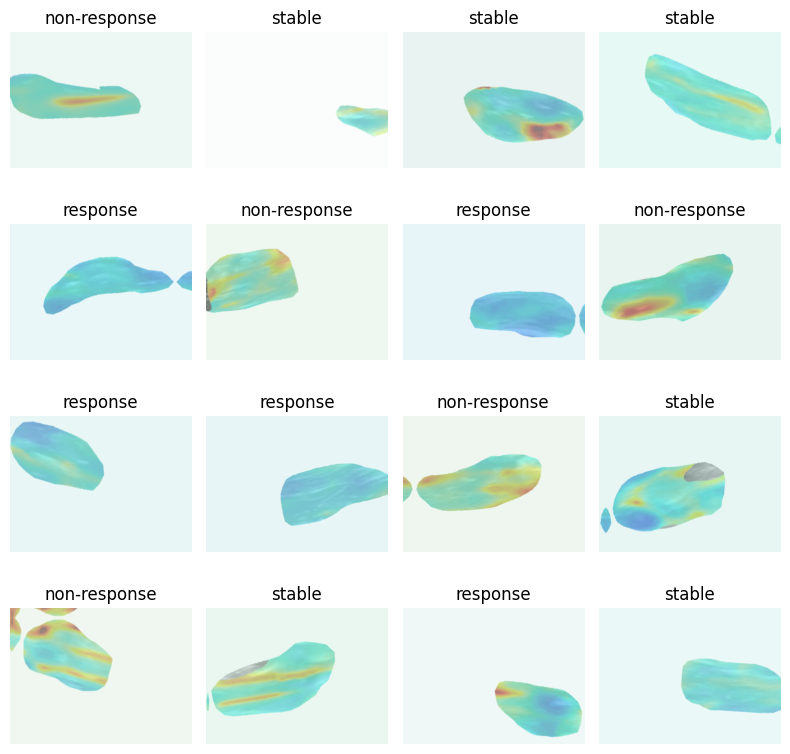

In [36]:
import matplotlib.pyplot as plt
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppress TF info logs
import tensorflow as tf

# Build a small visualization dataset with on‐the‐fly augmentation
vis_ds = make_dataset(
    X_img_temp,   # or whichever NumPy array holds all your images
    X_num_temp,   # numeric features
    y_temp,       # labels
    shuffle=True,
    augment_data=True
)

# Grab one batch of augmented images & labels
for (img_batch, _), label_batch in vis_ds.take(1):
    imgs = img_batch.numpy()             # shape (B, 300, 400, 3)
    labs = label_batch.numpy().astype(int)  # cast to int for indexing
    break

# Plot a grid of augmented images
grid_size = 4   # 4×4 grid = 16 images
plt.figure(figsize=(8, 8))
for i in range(grid_size * grid_size):
    plt.subplot(grid_size, grid_size, i + 1)
    plt.imshow(imgs[i])
    plt.title(class_names[labs[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [37]:
# Build tf.data.Dataset objects for Keras
train_ds = make_dataset(
    X_img_train, X_num_train, y_train,
    shuffle=True,  augment_data=True
)
val_ds = make_dataset(
    X_img_val, X_num_val, y_val,
    shuffle=False, augment_data=False
)
test_ds = make_dataset(
    X_img_test, X_num_test, y_test,
    shuffle=False, augment_data=False
)

In [38]:
from tensorflow import keras
from tensorflow.keras import layers, regularizers, Input, Model

def build_augm_cnn_multi():
    weight_decay = 1e-4
    dropout_rate = 0.3
    img_in = Input((IMG_HEIGHT, IMG_WIDTH, 3), name="image_input")

    # First block
    x = layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(weight_decay))(img_in)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)

    # Second block
    x = layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)

    # Third block
    x = layers.Conv2D(128, 3, padding='same', kernel_initializer='he_normal',
                      kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    last_conv = layers.Activation('relu', name="last_conv_act")(x)  # ← add this name
    x = layers.MaxPooling2D(2)(last_conv)
    x = layers.Dropout(dropout_rate)(x)

    # Global pooling
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(x)

    # Numeric branch
    num_in = Input((1,), name="numeric_input")
    y = layers.Dense(64, activation='relu')(num_in)
    y = layers.Dropout(dropout_rate)(y)

    # Fusion & head
    fusion = layers.Concatenate(name="fusion")([x, y])
    z = layers.Dense(128, kernel_regularizer=regularizers.l2(weight_decay))(fusion)
    z = layers.LeakyReLU(0.1)(z)
    z = layers.Dropout(dropout_rate)(z)
    out = layers.Dense(3, activation='softmax',
                       kernel_regularizer=regularizers.l2(weight_decay),
                       name="predictions")(z)

    return keras.Model([img_in, num_in], out, name="augmCNN_multi")


In [39]:
import tensorflow as tf

tf.keras.backend.clear_session()
final_model = build_augm_cnn_multi()

optimizer    = keras.optimizers.SGD(learning_rate=0.0035)
cosine_decay = tf.keras.optimizers.schedules.CosineDecay(0.0035, decay_steps=100)
lr_cb        = keras.callbacks.LearningRateScheduler(lambda e, lr: float(cosine_decay(e)), verbose=1)
rlrop        = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=25, verbose=1)
es_cb        = keras.callbacks.EarlyStopping(monitor="val_loss", patience=25,
                                             restore_best_weights=True, verbose=1)

final_model.compile(
    optimizer = optimizer,
    loss      = "sparse_categorical_crossentropy",
    metrics   = ["accuracy"]
)

history_final = final_model.fit(
    train_ds,
    epochs          = 100,
    validation_data = val_ds,
    callbacks       = [lr_cb, rlrop, es_cb],
    verbose         = 2
)


Epoch 1: LearningRateScheduler setting learning rate to 0.0035000001080334187.
Epoch 1/100


2025-08-21 13:20:01.524660: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inaugmCNN_multi/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-08-21 13:20:02.944374: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2025-08-21 13:20:05.235373: I external/local_xla/xla/service/service.cc:168] XLA service 0x7756e90349c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-21 13:20:05.235409: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
I0000 00:00:1755782405.287637     952 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


35/35 - 30s - loss: 1.1546 - accuracy: 0.4466 - val_loss: 1.1766 - val_accuracy: 0.3924 - lr: 0.0035 - 30s/epoch - 852ms/step

Epoch 2: LearningRateScheduler setting learning rate to 0.0034991365391761065.
Epoch 2/100
35/35 - 4s - loss: 0.9339 - accuracy: 0.6332 - val_loss: 1.1615 - val_accuracy: 0.3122 - lr: 0.0035 - 4s/epoch - 114ms/step

Epoch 3: LearningRateScheduler setting learning rate to 0.003496546996757388.
Epoch 3/100
35/35 - 4s - loss: 0.8018 - accuracy: 0.7011 - val_loss: 1.1113 - val_accuracy: 0.3122 - lr: 0.0035 - 4s/epoch - 114ms/step

Epoch 4: LearningRateScheduler setting learning rate to 0.0034922335762530565.
Epoch 4/100
35/35 - 4s - loss: 0.7151 - accuracy: 0.7346 - val_loss: 1.0871 - val_accuracy: 0.6118 - lr: 0.0035 - 4s/epoch - 116ms/step

Epoch 5: LearningRateScheduler setting learning rate to 0.0034862009342759848.
Epoch 5/100
35/35 - 4s - loss: 0.6570 - accuracy: 0.7781 - val_loss: 1.0653 - val_accuracy: 0.5654 - lr: 0.0035 - 4s/epoch - 116ms/step

Epoch 6: L

In [40]:
test_loss, test_acc = final_model.evaluate(test_ds, verbose=1)
print(f"Final test loss:     {test_loss:.4f}")
print(f"Final test accuracy: {test_acc:.4f}") 

8/8 [==============================] - 0s 16ms/step - loss: 0.4806 - accuracy: 0.8734
Final test loss:     0.4806
Final test accuracy: 0.8734


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

In [42]:
# ──────────────────────────────────────────────────────────────────────────────
# SAVE your final history to disk (once, right after .fit)
# ──────────────────────────────────────────────────────────────────────────────
np.save('augmCNN_multi_history.npy', history_final.history)

In [43]:
# ──────────────────────────────────────────────────────────────────────────────
# LOAD the history back in
# ──────────────────────────────────────────────────────────────────────────────
hist = np.load('augmCNN_multi_history.npy', allow_pickle=True).item()
df1 = pd.DataFrame({
    'lr':           hist['lr'],
    'loss':         hist['loss'],
    'accuracy':     hist['accuracy'],
    'val_loss':     hist['val_loss'],
    'val_accuracy': hist['val_accuracy']
})
print(df1.head())

         lr      loss  accuracy  val_loss  val_accuracy
0  0.003500  1.154608  0.446558  1.176569      0.392405
1  0.003499  0.933902  0.633152  1.161547      0.312236
2  0.003497  0.801798  0.701087  1.111283      0.312236
3  0.003492  0.715123  0.734601  1.087126      0.611814
4  0.003486  0.656970  0.778080  1.065309      0.565401


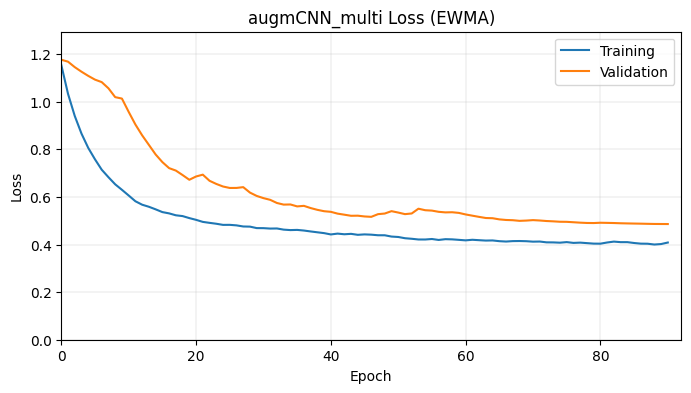

In [58]:
# Loss
plt.figure(figsize=(8,4))
ax = df1['loss'].ewm(span=10).mean().plot(label='Training')
df1['val_loss'].ewm(span=10).mean().plot(label='Validation', ax=ax)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
plt.grid(linewidth=0.2)
plt.ylim(0, df1[['loss','val_loss']].max().max() * 1.1)
plt.xlim(0, 92)  # Force x-axis to show 0-60
plt.legend(loc='upper right')
plt.title('augmCNN_multi Loss (EWMA)')
plt.savefig("augmCNN_multi_loss.pdf", bbox_inches='tight')
plt.show()

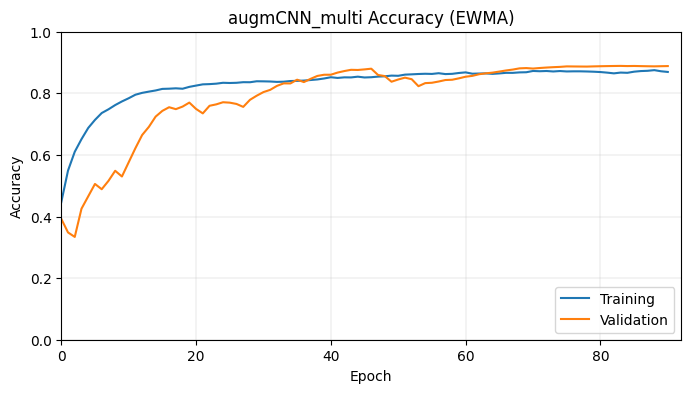

In [59]:
# Accuracy
plt.figure(figsize=(8,4))
ax = df1['accuracy'].ewm(span=10).mean().plot(label='Training')
df1['val_accuracy'].ewm(span=10).mean().plot(label='Validation', ax=ax)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
plt.grid(linewidth=0.2)
plt.ylim(0,1)
plt.xlim(0, 92)  # Force x-axis to show 0-60
plt.legend(loc='lower right')
plt.title('augmCNN_multi Accuracy (EWMA)')
plt.savefig("augmCNN_multi_accuracy.pdf", bbox_inches='tight')
plt.show()

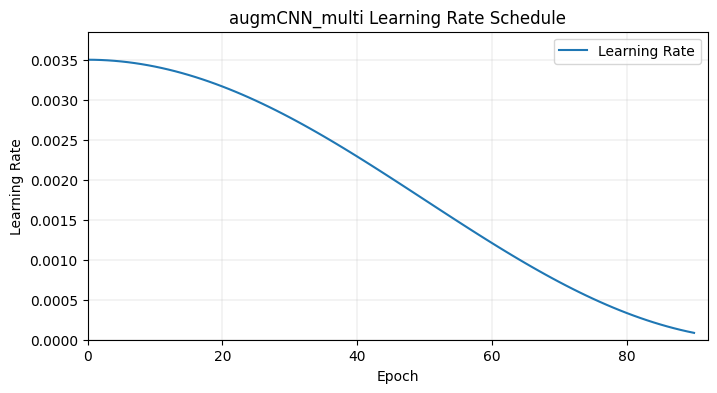

In [60]:
# Learning Rate
plt.figure(figsize=(8,4))
ax = df1['lr'].plot(label='Learning Rate')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
plt.grid(linewidth=0.2)
plt.ylim(0, df1['lr'].max()*1.1)
plt.xlim(0, 92)  # Force x-axis to show 0-60
plt.legend(loc='upper right')
plt.title('augmCNN_multi Learning Rate Schedule')
plt.savefig("augmCNN_multi_lr.pdf", bbox_inches='tight')
plt.show()

8/8 [==============================] - 0s 14ms/step


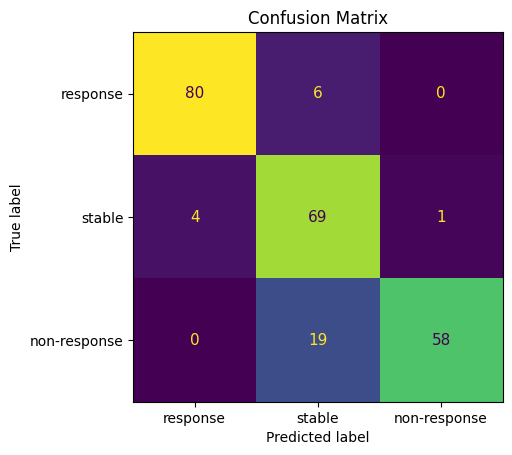

              precision    recall  f1-score   support

    response       0.95      0.93      0.94        86
      stable       0.73      0.93      0.82        74
non-response       0.98      0.75      0.85        77

    accuracy                           0.87       237
   macro avg       0.89      0.87      0.87       237
weighted avg       0.89      0.87      0.88       237



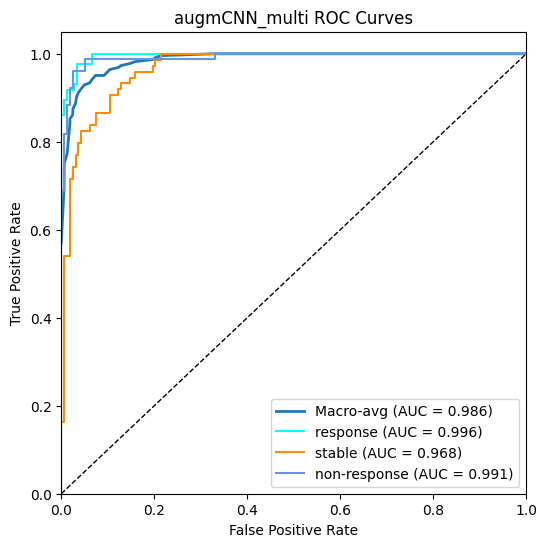

In [47]:
# ──────────────────────────────────────────────────────────────────────────────
# FINAL PREDICTIONS & METRICS
# ──────────────────────────────────────────────────────────────────────────────
# Use the same test_ds you built earlier, so images & numerics match training
y_score = final_model.predict(test_ds, verbose=1)  
y_pred  = np.argmax(y_score, axis=1)
y_true  = y_test  # your NumPy array of true labels

# 1) Confusion Matrix
cf_matrix = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cf_matrix, display_labels=class_names)
disp.plot(colorbar=False, cmap='viridis', text_kw={'fontsize':11})
plt.title('Confusion Matrix')
plt.show()

# 2) Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))

# 3) ROC Curves & AUC
y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
n_classes  = y_true_bin.shape[1]

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i]        = auc(fpr[i], tpr[i])

# macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.mean([np.interp(all_fpr, fpr[i], tpr[i]) for i in range(n_classes)], axis=0)
fpr["macro"], tpr["macro"] = all_fpr, mean_tpr
roc_auc["macro"] = auc(all_fpr, mean_tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-avg (AUC = {roc_auc["macro"]:.3f})', lw=2)
colors = ['aqua','darkorange','cornflowerblue']
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlim(0,1); plt.ylim(0,1.05)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('augmCNN_multi ROC Curves')
plt.legend(loc='lower right')
plt.show()

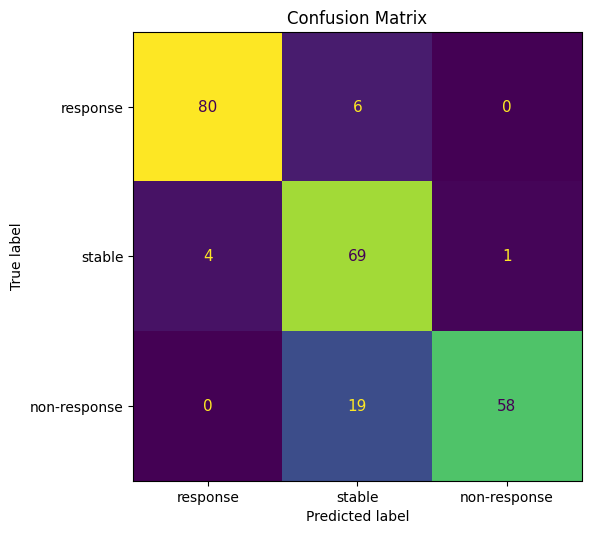

In [48]:
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(cf_matrix, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='viridis', text_kw={'fontsize': 11})
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("confusion_matrix.pdf", bbox_inches='tight')
plt.show()

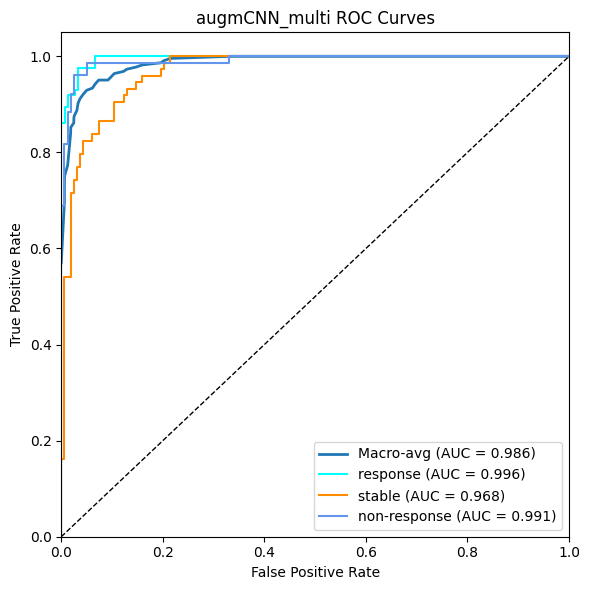

In [49]:
plt.figure(figsize=(6,6))
plt.plot(fpr["macro"], tpr["macro"],
         label=f'Macro-avg (AUC = {roc_auc["macro"]:.3f})', lw=2)
colors = ['aqua','darkorange','cornflowerblue']
for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlim(0,1); plt.ylim(0,1.05)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('augmCNN_multi ROC Curves')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("roc_curve.pdf", bbox_inches='tight')  # <---- save as PDF
plt.show()

In [50]:
# After you’ve computed fpr, tpr and roc_auc, dump them to disk:
import numpy as np

np.savez(
    "roc_data_augmentation.npz",
    fpr=fpr,
    tpr=tpr,
    roc_auc=roc_auc
)

In [51]:
!pip install seaborn -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
import seaborn as sns
import tensorflow as tf
import cv2


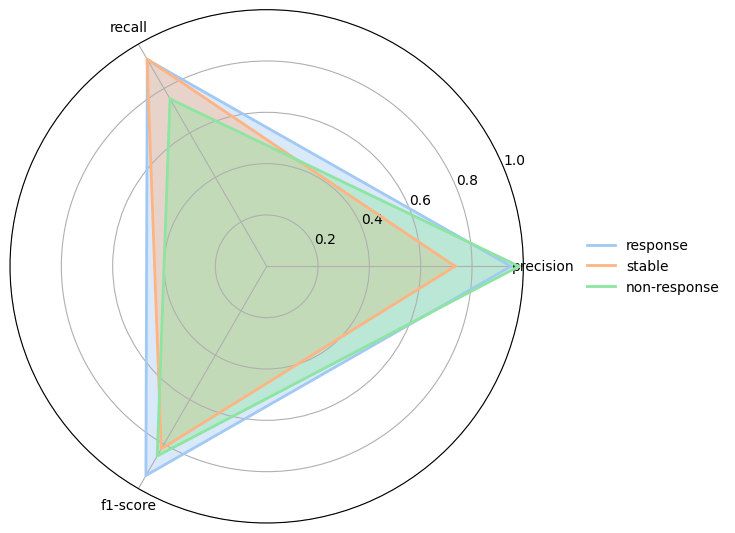

In [53]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

# If you already have y_true, y_pred, class_names, skip this assignment
# y_true = y_test
# y_pred = np.argmax(y_score, axis=1)

report_dict = classification_report(y_true, y_pred, output_dict=True, target_names=class_names)
metrics = ['precision', 'recall', 'f1-score']
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # Close the loop

pastel_colors = ['#a1c9f4', '#ffb482', '#8de5a1']

fig, ax = plt.subplots(figsize=(7, 6), subplot_kw=dict(polar=True))

for i, label in enumerate(class_names):
    values = [report_dict[label][metric] for metric in metrics]
    values += values[:1]
    ax.plot(angles, values, label=label, color=pastel_colors[i], linewidth=2)
    ax.fill(angles, values, color=pastel_colors[i], alpha=0.4)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)

# Move legend outside to the right
ax.legend(loc='center left', bbox_to_anchor=(1.1, 0.5), frameon=False)

plt.tight_layout()
plt.savefig("radar_metrics_filled.pdf", bbox_inches='tight')
plt.show()

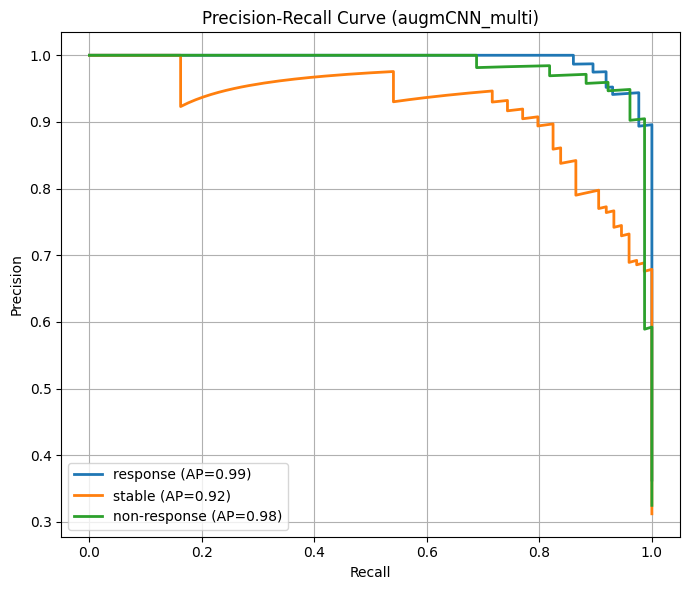

In [54]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Binarize true labels for multi-class PR curves
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])  # Change classes if needed

plt.figure(figsize=(7, 6))
for i in range(len(class_names)):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
    ap = average_precision_score(y_true_bin[:, i], y_score[:, i])
    plt.plot(recall, precision, label=f"{class_names[i]} (AP={ap:.2f})", linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (augmCNN_multi)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("precision_recall_curve.pdf", bbox_inches='tight')
plt.show()

In [55]:
import tensorflow as tf

# Build a feature extractor for the 'fusion' layer
feature_extractor = tf.keras.Model(
    inputs=final_model.inputs,
    outputs=final_model.get_layer('fusion').output
)

# Get fusion features from the test set
fusion_features = feature_extractor.predict([X_img_test, X_num_test], batch_size=32)

8/8 [==============================] - 0s 14ms/step


In [56]:
!pip install -q seaborn


[notice] A new release of pip is available: 23.3.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


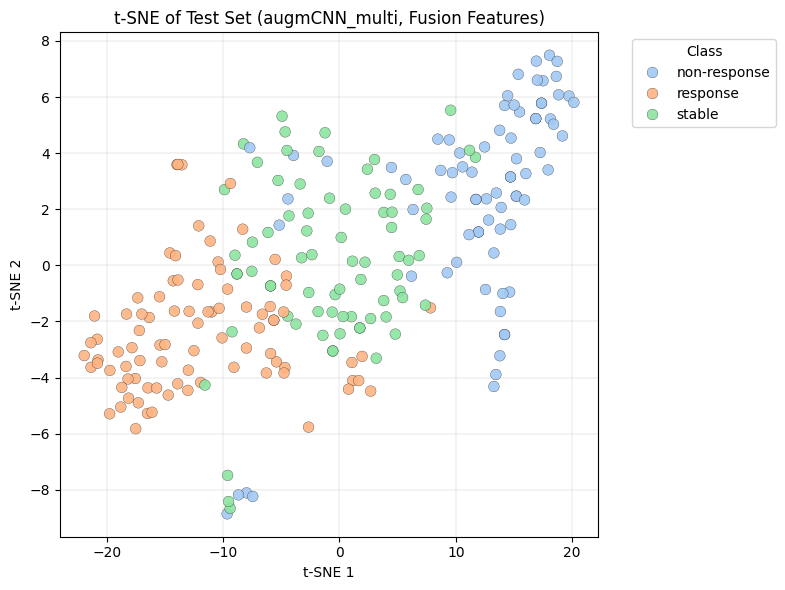

In [57]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# In case y_test is float, convert to int
y_labels_int = np.array(y_test).astype(int)

# t-SNE to 2D
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(fusion_features)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    hue=[class_names[y] for y in y_labels_int],
    palette='pastel', s=60, alpha=0.9, edgecolor="k", linewidth=0.2
)
plt.title("t-SNE of Test Set (augmCNN_multi, Fusion Features)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True, linewidth=0.2)
plt.legend(title='Class', loc='best', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig("tsne_fusion_features.pdf", bbox_inches='tight')
plt.show()

BATCH after pipeline: float32 0.3507158 0.9857162 (32, 300, 400, 3)


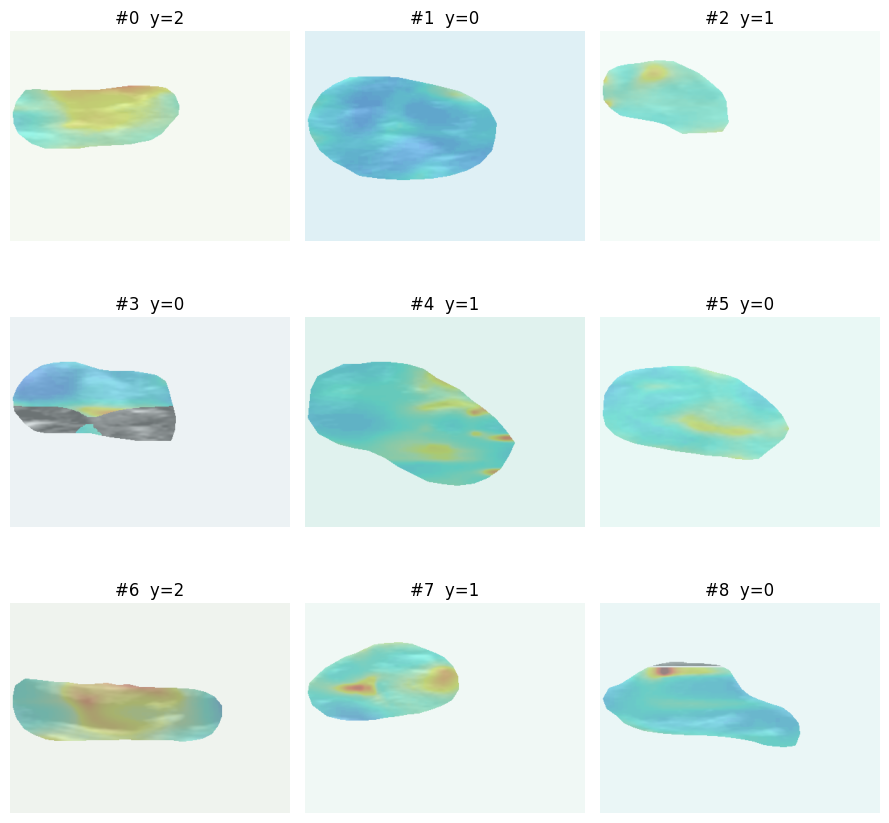

In [76]:
# test_ds was built with augment_data=False, so only preprocess() runs
for (imgs_b, nums_b), labs_b in test_ds.take(1):
    imgs_b_np = imgs_b.numpy()
    print("BATCH after pipeline:", imgs_b_np.dtype, imgs_b_np.min(), imgs_b_np.max(), imgs_b_np.shape)

    # show a few
    import math
    k = min(9, imgs_b_np.shape[0])
    cols = 3
    rows = math.ceil(k/cols)
    plt.figure(figsize=(3*cols, 3*rows))
    for j in range(k):
        plt.subplot(rows, cols, j+1)
        plt.imshow(np.clip(imgs_b_np[j],0,1))
        plt.title(f"#{j}  y={int(labs_b.numpy()[j])}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    break

In [75]:
print(np.unique(y_test, return_counts=True))   # Class distribution in your test set
preds = np.argmax(final_model.predict(test_ds), axis=1)
print(np.unique(preds, return_counts=True))    # What classes is the model actually predicting?

(array([0., 1., 2.], dtype=float32), array([86, 74, 77]))
8/8 [==============================] - 0s 23ms/step
(array([0, 1, 2]), array([85, 92, 60]))
